In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/CSRES_4v3_500_1000gene/TH_downsampled.h5ad")

In [3]:
adata.obs["celltype.L2"].value_counts()

celltype.L2
Astrocyte-1                5724
TH Tll1_Thsd7b Glut        4821
TH Tnc_Cdh20 Glut          4352
TH Car4_Tspan11 Glut       4211
TH Cald1_Gm39185 Glut      3249
TH Fam20a_Fbln1 Glut       2954
MOL-1                      2719
MOL-2                      2279
OPC                        2167
TH Kcnk13_Nox4 Glut        2147
TH Ccdc192_Gli3 Glut       2023
TH Meis2_Gm2115 GABA       1988
TH Parm1_Mdga1 Glut        1497
TH Fgf10_Gm16263 Glut      1332
MOL-3                      1215
TH Egflam_Fbn2 Glut        1113
MFOL                        601
TH Tac2_Pde11a Glut         311
Astrocyte-3                 284
Choroid plexus cell         274
COP                         237
TH Col27a1_Npsr1 Glut       190
Astrocyte-4                 149
Microglia-1                 141
Ependymal cell              119
NFOL                         65
Microglia-2                  57
Tanycyte                     56
VLMC                         41
Endothelial cell             33
Astrocyte-2                 

In [4]:
adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]
#去掉名字包含MW22B的样本
adata_subset = adata_subset[~adata_subset.obs["sample"].str.contains("MW22B")]

In [5]:
# 探索 subset 数据结构
print(f"adata_subset shape: {adata_subset.shape}")
print(f"Obs columns: {list(adata_subset.obs.columns)}")
print(f"X type: {type(adata_subset.X)}")
print(f"X min/max: {adata_subset.X.min():.4f} / {adata_subset.X.max():.4f}")
print(f"细胞数量: {adata_subset.n_obs}")
print(f"基因数量: {adata_subset.n_vars}")
print()
# 查看分组信息
print("celltype.L2 value counts:")
print(adata_subset.obs["celltype.L2"].value_counts())
print()
# 查看是否有 batch 信息
for col in adata_subset.obs.columns:
    if "batch" in col.lower():
        print(f"Batch column: {col}")
        print(adata_subset.obs[col].value_counts())

adata_subset shape: (3973, 16428)
Obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'scrublet_score', 'predicted_doublets', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'date', 'status', 'sex', 'donor', 'region', 'company', 'cells_number', 'fraction_reads', 'mean_reads', 'median_umi', 'median_genes', 'total_genes', 'mapped_genome', 'mapped_confidently_genome', 'mapped_intergenic', 'mapped_intronic', 'mapped_exonic', 'mapped_transcriptome', 'antisense_gene', 'reads_number', 'valid_barcodes', 'sequencing_saturation', 'q30_barcode', 'q30_rna', 'q30_umi', 'tech', 'batch', 'predicted_labels'

In [6]:
# 查看可用于分组的列
for col in ["status", "region", "sex", "donor", "date"]:
    if col in adata_subset.obs.columns:
        print(f"\n{col} value counts:")
        print(adata_subset.obs[col].value_counts().head(20))


status value counts:
status
CSRES    2140
CON      1833
Name: count, dtype: int64

region value counts:
region
TH    3973
Name: count, dtype: int64

sex value counts:
sex
M    3973
Name: count, dtype: int64

donor value counts:
donor
CSRS1-3     928
CSRS10-3    644
MW47A       633
MW51A       619
MW45A       581
CSRS9-1     568
Name: count, dtype: int64

date value counts:
date
20250728    2140
20250102    1200
20250107     633
Name: count, dtype: int64


In [7]:
# 检查 adata 是否有 raw 或 layers
print("Has raw:", adata.raw is not None)
if hasattr(adata, 'layers'):
    print("Layers keys:", list(adata.layers.keys()))
print("adata_subset.X shape:", adata_subset.X.shape)
print("adata_subset.X type:", type(adata_subset.X))

# 检查 var 是否有基因名
print("\nvar columns:", list(adata_subset.var.columns[:20]))
print("var index head:", adata_subset.var.index[:5].tolist())

Has raw: False
Layers keys: ['counts', None]
adata_subset.X shape: (3973, 16428)
adata_subset.X type: <class 'anndata._core.views.SparseCSRMatrixView'>

var columns: ['gene_ids']
var index head: ['Xkr4', 'Gm1992', 'Gm19938', 'Rp1', 'Mrpl15']


In [8]:
import sys
sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
from model import RUVVAE_DEG, compute_deg

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# 设置
batch_key = "batch"
group_key = "status"
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [9]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # 在大规模跨组织分析中相对稳定
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # 小鼠脑中报告相对稳定的基础基因
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA加工、核质运输与基础细胞维护
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # 可作为补充候选，但必须在本数据中验证
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes 

In [10]:
# ========== 1. 准备数据（全部基因） ==========
adata_hvg = adata_subset.copy()

# 清理数据中的 inf/nan
X_data = adata_hvg.X.toarray() if hasattr(adata_hvg.X, 'toarray') else adata_hvg.X.copy()
X_data = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)
adata_hvg.X = X_data

# Normalizing to median total counts
sc.pp.normalize_total(adata_hvg)
# Logarithmize the data
sc.pp.log1p(adata_hvg)

# 使用全部基因（不做 HVG 筛选）
n_genes_total = adata_hvg.n_vars
Y_all = X_data  # (n_cells, n_genes)
gene_names = adata_hvg.var.index.tolist()
print(f"基因总数: {n_genes_total}")
print(f"表达矩阵形状: {Y_all.shape}")
print(f"表达矩阵范围: {Y_all.min():.4f} ~ {Y_all.max():.4f}")

# 分组标签
group_labels = adata_hvg.obs[group_key].values
groups_unique = sorted(np.unique(group_labels).tolist())
print(f"分组: {groups_unique}")
print(f"CON: {(group_labels==groups_unique[0]).sum()}, CSDS: {(group_labels==groups_unique[1]).sum()}")

# 批次标签
batch_labels = adata_hvg.obs[batch_key].values
batches_unique = sorted(np.unique(batch_labels).tolist())
print(f"批次数量: {len(batches_unique)}")
print(f"批次: {batches_unique}")

基因总数: 16428
表达矩阵形状: (3973, 16428)
表达矩阵范围: 0.0000 ~ 7.7059
分组: ['CON', 'CSRES']
CON: 1833, CSDS: 2140
批次数量: 6
批次: ['CSRS1-3_TH_beirui', 'CSRS10-3_TH_beirui', 'CSRS9-1_TH_beirui', 'MW45A_TH_beirui', 'MW47A_TH_seekgene', 'MW51A_TH_beirui']


In [11]:
# ========== 2. 选择负对照基因（HKG 文献池 + 数据驱动） ==========

# ---------- 用户选项：NC 选择策略 ----------
NC_MODE = "data_only"  # 选项: "data_only", "hkg_only", "hybrid"

# ---------- 2a. 定义 HKG 候选函数（适配小鼠基因名） ----------
import re

def build_candidate_nc_genes_mouse(gene_names):
    """构造候选负对照基因池（适配小鼠 gene symbol 大小写）"""
    
    # 1) 文献 curated housekeeping（Eisenberg & Levanon 2013, 转小鼠大小写）
    eisenberg_hkg = {
        "Actb", "B2m", "Gapdh", "Hmbs", "Hprt1", "Pgk1", "Ppia",
        "Rpl13a", "Rplp0", "Sdha", "Tbp", "Tfrc", "Ubc", "Vcp",
        "Ywhaz", "C1orf43", "Chmp2a", "Emc7", "Gpi", "Psmb2",
        "Psmb4", "Rab7a", "Reep5", "Snrpd3", "Vps29",
        "Cltc", "Csnk2b", "Ddx5", "Eef1a1", "Eif4a2",
        "Hnrnpk", "Nono", "Rpl32", "Rps18", "Sf3b1",
        "Srsf3", "Sumo1", "Ube2d2", "Usp22", "Xrn2",
    }
    
    # 2) 核糖体蛋白（细胞质 + 线粒体）
    rp_genes = {g for g in gene_names 
                if re.match(r'^(RP[SL]|Mrp[sl]|Rps|Rpl)[0-9]', g, re.IGNORECASE)}
    
    # 3) 翻译延伸因子
    eef_genes = {g for g in gene_names if re.match(r'^(Eef[12]|EIF)', g, re.IGNORECASE)}
    
    # 4) 蛋白酶体亚基
    psm_genes = {g for g in gene_names if re.match(r'^(Psm|PSM)[A-Da-d][0-9]', g)}
    
    # 5) 线粒体核糖体蛋白
    mrp_genes = {g for g in gene_names if re.match(r'^Mrp[sl][0-9]', g, re.IGNORECASE)}
    
    candidate = (eisenberg_hkg & set(gene_names)) | rp_genes | eef_genes | psm_genes | mrp_genes
    return np.array([g in candidate for g in gene_names])


# ---------- 2b. 计算表达矩阵 ----------
counts = adata_hvg.layers["counts"].toarray()
counts = np.nan_to_num(counts, nan=0.0, posinf=0.0, neginf=0.0)
Y_log = np.log1p(counts)

# 按 status 分组计算均值
mask_con = group_labels == groups_unique[0]
mask_csds = group_labels == groups_unique[1]
mean_con = Y_log[mask_con].mean(0)
mean_csds = Y_log[mask_csds].mean(0)
fc_abs = np.abs(mean_csds - mean_con)  # 两组间 logFC 绝对值

# ---------- 2c. 构造 HKG + 优先列表 ----------
hkg_mask = build_candidate_nc_genes_mouse(gene_names)
print(f"HKG 候选基因（文献+核糖体+蛋白酶体等）: {hkg_mask.sum()}")

# 用户自定义的优先 HKG 列表（确保它们一定在内参中）
priority_mask = np.zeros(n_genes_total, dtype=bool)
for hkg in hkg_priority:
    if hkg in gene_names:
        idx = gene_names.index(hkg)
        priority_mask[idx] = True
print(f"优先 HKG 列表命中: {priority_mask.sum()} / {len(hkg_priority)}")

# HKG 总池 = 文献候选 + 优先列表
hkg_combined_mask = hkg_mask | priority_mask

# ---------- 2d. 根据 NC_MODE 选择负对照基因 ----------
n_nc_total = 500  # 总负对照基因数

if NC_MODE == "data_only":
    # 纯数据驱动：从全部基因中挑选 logFC 最小的 n_nc_total 个
    nc_idx = np.argsort(fc_abs)[:n_nc_total]
    print(f"[模式: data_only] 从全部 {n_genes_total} 基因中按 |logFC| 排序挑 {n_nc_total} 个")

elif NC_MODE == "hkg_only":
    # 纯先验知识：只用 HKG 文献池 + 优先列表
    available_hkg_idx = np.where(hkg_combined_mask)[0]
    if len(available_hkg_idx) >= n_nc_total:
        # HKG 多于目标，按 |logFC| 排序挑最小的
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hkg_only] 从 HKG 池（{len(available_hkg_idx)}）中挑 {n_nc_total} 个")
    else:
        # HKG 不够，全部用上
        nc_idx = available_hkg_idx
        print(f"[模式: hkg_only] HKG 仅 {len(available_hkg_idx)} 个，全部用上")

elif NC_MODE == "hybrid":
    # 混合：先验 HKG + 数据驱动补足
    n_hkg = hkg_combined_mask.sum()
    if n_hkg >= n_nc_total:
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hybrid] HKG={n_hkg} ≥ {n_nc_total}，从 HKG 中挑 |logFC| 最小的")
    else:
        remaining = n_nc_total - n_hkg
        non_hkg_fc = fc_abs.copy()
        non_hkg_fc[hkg_combined_mask] = np.inf
        data_idx = np.argsort(non_hkg_fc)[:remaining]
        nc_idx = np.concatenate([np.where(hkg_combined_mask)[0], data_idx])
        print(f"[模式: hybrid] HKG={n_hkg} 全部保留 + 数据驱动补 {remaining} 个")
else:
    raise ValueError(f"NC_MODE = {NC_MODE} 不支持，请用 'data_only' / 'hkg_only' / 'hybrid'")

neg_control_mask = np.zeros(n_genes_total, dtype=bool)
neg_control_mask[nc_idx] = True

# ---------- 2e. 打印详细统计 ----------
nc_hkg_overlap = neg_control_mask & hkg_combined_mask
nc_priority_overlap = neg_control_mask & priority_mask
print(f"\n最终负对照基因: {neg_control_mask.sum()}")
print(f"  其中 HKG 文献候选: {nc_hkg_overlap.sum()}")
print(f"  其中优先 HKG 列表: {nc_priority_overlap.sum()}")
print(f"  其中非 HKG（仅 hybrid 模式）: {neg_control_mask.sum() - nc_hkg_overlap.sum()}")
print(f"\n负对照基因 (前10): {[gene_names[i] for i in nc_idx[:10]]}")
print(f"负对照基因 logFC 范围: {fc_abs[nc_idx].min():.4f} ~ {fc_abs[nc_idx].max():.4f}")

HKG 候选基因（文献+核糖体+蛋白酶体等）: 301
优先 HKG 列表命中: 17 / 17
[模式: data_only] 从全部 16428 基因中按 |logFC| 排序挑 500 个

最终负对照基因: 500
  其中 HKG 文献候选: 7
  其中优先 HKG 列表: 0
  其中非 HKG（仅 hybrid 模式）: 493

负对照基因 (前10): ['E130119H09Rik', 'Mroh3', 'Gm45025', 'Neurod6', 'Tcp11', 'Olfr1033', 'Usp26', 'Bcl2l12', '1700007K13Rik', 'Fcgr3']
负对照基因 logFC 范围: 0.0000 ~ 0.0005


In [12]:
# ========== 3. 训练 RUVVAE_DEG ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 初始化模型（使用全部基因数）
model = RUVVAE_DEG(
    n_genes=n_genes_total,
    n_group=2,
    n_batch=len(batches_unique),
    d_bio=32,
    k_unk=5
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# 准备 covariate 字典
group_idx = np.array([groups_unique.index(g) for g in group_labels])
c_dict = {"group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]).to(device)}

batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
c_dict["batch"] = torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]).to(device)

# 转换数据为 tensor
Y_t = torch.FloatTensor(Y_log).to(device)
nc_mask_t = torch.BoolTensor(neg_control_mask).to(device)

n_epochs = 200
batch_size = 256
n_cells = Y_t.shape[0]

loss_history = {"total": [], "recon": [], "kl_z": [], "kl_w": [], "nc": []}

print(f"开始训练 {n_epochs} epochs, batch_size={batch_size}...")
for epoch in range(n_epochs):
    perm = torch.randperm(n_cells)
    epoch_losses = {"total": 0, "recon": 0, "kl_z": 0, "kl_w": 0, "nc": 0}
    n_batches = 0
    
    for i in range(0, n_cells, batch_size):
        idx = perm[i:i+batch_size]
        y_batch = Y_t[idx]
        
        batch_c_dict = {}
        for k, v in c_dict.items():
            batch_c_dict[k] = v[idx]
        
        optimizer.zero_grad()
        out = model(y_batch, batch_c_dict, nc_mask_t)
        losses = out["losses"]
        
        loss = losses["recon"] + 1e-3 * losses["kl_z"] + 1e-3 * losses["kl_w"] + 1.0 * losses["nc_total"]
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        epoch_losses["total"] += loss.item()
        epoch_losses["recon"] += losses["recon"].item()
        epoch_losses["kl_z"] += losses["kl_z"].item()
        epoch_losses["kl_w"] += losses["kl_w"].item()
        epoch_losses["nc"] += losses["nc_total"].item()
        n_batches += 1
    
    scheduler.step(epoch_losses["total"] / n_batches)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Loss: {epoch_losses['total']/n_batches:.4f} | "
              f"Recon: {epoch_losses['recon']/n_batches:.4f} | "
              f"KL_z: {epoch_losses['kl_z']/n_batches:.4f} | "
              f"KL_w: {epoch_losses['kl_w']/n_batches:.4f} | "
              f"NC: {epoch_losses['nc']/n_batches:.4f}")
    
    for k in loss_history:
        loss_history[k].append(epoch_losses[k] / n_batches)

print("训练完成！")

使用设备: cuda
开始训练 200 epochs, batch_size=256...
Epoch  20/200 | Loss: 0.1170 | Recon: 0.1031 | KL_z: 1.5116 | KL_w: 0.6694 | NC: 0.0117
Epoch  40/200 | Loss: 0.1120 | Recon: 0.0987 | KL_z: 1.3020 | KL_w: 0.3209 | NC: 0.0117
Epoch  60/200 | Loss: 0.1104 | Recon: 0.0974 | KL_z: 1.1378 | KL_w: 0.1749 | NC: 0.0117
Epoch  80/200 | Loss: 0.1089 | Recon: 0.0961 | KL_z: 1.0521 | KL_w: 0.1195 | NC: 0.0117
Epoch 100/200 | Loss: 0.1082 | Recon: 0.0954 | KL_z: 1.0012 | KL_w: 0.0805 | NC: 0.0117
Epoch 120/200 | Loss: 0.1070 | Recon: 0.0943 | KL_z: 0.9902 | KL_w: 0.0489 | NC: 0.0116
Epoch 140/200 | Loss: 0.1063 | Recon: 0.0936 | KL_z: 0.9977 | KL_w: 0.0302 | NC: 0.0117
Epoch 160/200 | Loss: 0.1054 | Recon: 0.0926 | KL_z: 1.0292 | KL_w: 0.0187 | NC: 0.0117
Epoch 180/200 | Loss: 0.1045 | Recon: 0.0918 | KL_z: 1.0672 | KL_w: 0.0102 | NC: 0.0117
Epoch 200/200 | Loss: 0.1037 | Recon: 0.0910 | KL_z: 1.0964 | KL_w: 0.0047 | NC: 0.0116
训练完成！


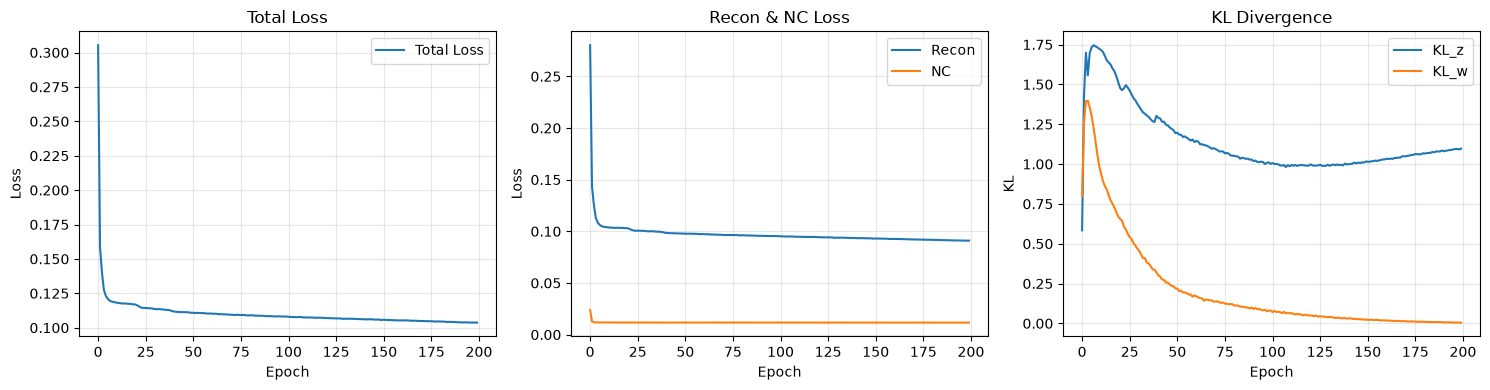

In [13]:
# ========== 4. 训练损失可视化 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history["total"], label="Total Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Total Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history["recon"], label="Recon")
axes[1].plot(loss_history["nc"], label="NC")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].set_title("Recon & NC Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(loss_history["kl_z"], label="KL_z")
axes[2].plot(loss_history["kl_w"], label="KL_w")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("KL"); axes[2].set_title("KL Divergence")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
# ========== 5. 计算 DEG（在 CPU 上进行） ==========
import importlib
import model as model_module
importlib.reload(model_module)
from model import RUVVAE_DEG, compute_deg

model_cpu = model.cpu()
deg_df, extra = compute_deg(
    model_cpu,
    Y_log,  # log1p 归一化矩阵
    gene_names,
    group_labels,
    groups_unique,
    neg_control_mask,
    batch_labels=batch_labels,
    n_posterior=200,
    n_perm=500
)

print(f"DEG 结果: {deg_df.shape[0]} 个基因")
print(f"\n列名: {list(deg_df.columns)}")

# ---------- 5a. Top 20 DEG（按 GLM delta p-value 排序） ----------
print(f"\nTop 20 DEG (按 GLM delta p_value 排序):")
top_deg = deg_df.sort_values("p_value_glm_delta").head(20)
display(top_deg[["gene", "logFC_bio", "se_glm",
                  "p_value_glm_delta", "p_value_empirical_t",
                  "p_value_perm", "p_value_bayes"]])

# ---------- 5b. 三种 p-value 方法的显著 DEG 数 + FDR 校正 ----------
from scipy.stats import false_discovery_control

p_methods = {
    "GLM delta (Wald)":   "p_value_glm_delta",
    "Welch's t-test":     "p_value_empirical_t",
    "Permutation (500x)": "p_value_perm",
    "Bayesian (后验符号)": "p_value_bayes",
}

print(f"\n=== 不同 p-value 方法下的显著 DEG 数 + FDR 校正 ===")
print(f"{'方法':<24} {'p<0.05':>8} {'p<0.01':>8} {'FDR<0.05':>10} {'FDR<0.01':>10} {'FDR<0.10':>10}")
print("-" * 76)

deg_counts = {}
for name, col in p_methods.items():
    pvals = deg_df[col].values
    if np.any(np.isnan(pvals)):
        # permutation 可能 NaN，跳过 FDR
        valid = ~np.isnan(pvals)
        fdr = np.full_like(pvals, np.nan)
        try:
            fdr_valid = false_discovery_control(pvals[valid])
            fdr[valid] = fdr_valid
        except Exception:
            pass
        n_sig = (pvals < 0.05).sum()
        n_sig01 = (pvals < 0.01).sum()
        n_fdr05 = ((fdr < 0.05) & valid).sum()
        n_fdr01 = ((fdr < 0.01) & valid).sum()
        n_fdr10 = ((fdr < 0.10) & valid).sum()
    else:
        n_sig = (pvals < 0.05).sum()
        n_sig01 = (pvals < 0.01).sum()
        try:
            fdr = false_discovery_control(pvals)
            n_fdr05 = (fdr < 0.05).sum()
            n_fdr01 = (fdr < 0.01).sum()
            n_fdr10 = (fdr < 0.10).sum()
            # 把 FDR 也存到 DataFrame
            deg_df[col.replace("p_value", "fdr")] = fdr
        except Exception:
            n_fdr05 = n_fdr01 = n_fdr10 = -1

    deg_counts[name] = {
        "p<0.05": int(n_sig), "p<0.01": int(n_sig01),
        "FDR<0.05": int(n_fdr05), "FDR<0.01": int(n_fdr01),
        "FDR<0.10": int(n_fdr10),
    }
    print(f"{name:<24} {n_sig:>8} {n_sig01:>8} {n_fdr05:>10} {n_fdr01:>10} {n_fdr10:>10}")

# ---------- 5c. 共识 DEG（在多种方法下同时显著） ----------
print(f"\n=== 多方法共识 DEG（GLM & Welch & Permutation 都 p<0.05）===")
consensus = (deg_df["p_value_glm_delta"] < 0.05) & \
            (deg_df["p_value_empirical_t"] < 0.05) & \
            (deg_df["p_value_perm"] < 0.05)
deg_df["consensus_sig"] = consensus
print(f"共识 DEG (三种都 p<0.05): {consensus.sum()}")
print(f"  其中上调 (logFC > 0): {(consensus & (deg_df['logFC_bio'] > 0)).sum()}")
print(f"  其中下调 (logFC < 0): {(consensus & (deg_df['logFC_bio'] < 0)).sum()}")

# ---------- 5d. 校正后列名汇总 ----------
print(f"\n校正后的 fdr 列已加入 deg_df:")
fdr_cols = [c for c in deg_df.columns if c.startswith("fdr_")]
print(fdr_cols)

DEG 结果: 16428 个基因

列名: ['gene', 'logFC_group', 'logFC_bio_latent', 'logFC_bio', 'logFC_bio_posterior_mean', 'logFC_bio_posterior_std', 'logFC_bio_ci_low', 'logFC_bio_ci_high', 'logFC_uv_group', 'logFC_uv_linear', 'logFC_uv_latent', 'logFC_uv_cov', 'logFC_uv_total', 'logFC_uv_posterior_mean', 'logFC_uv_posterior_std', 'se_glm', 't_stat', 'p_value_bayes', 'p_value_empirical_t', 'p_value_glm_delta', 'p_value_perm']

Top 20 DEG (按 GLM delta p_value 排序):


,gene,logFC_bio,se_glm,p_value_glm_delta,p_value_empirical_t,p_value_perm,p_value_bayes
4915,Baz1b,0.362306,0.008848,1.000000e-300,2.672164e-278,0.001996,0.0
7591,Mmaa,0.226075,0.005828,1.000000e-300,8.705755e-194,0.001996,0.0
11658,Sp4,0.211871,0.005651,1.000000e-300,3.712773e-179,0.001996,0.0
13439,Arf3,0.186541,0.004885,1.000000e-300,7.902484e-150,0.001996,0.0
8862,Trank1,0.459593,0.010730,1.000000e-300,1.000000e-300,0.001996,0.0
8871,Ubp1,0.251950,0.005605,1.000000e-300,6.690057e-219,0.001996,0.0
10910,Foxj1,0.009293,0.000242,1.000000e-300,9.757552e-01,0.001996,0.0
10911,Rnf157,0.300099,0.007569,1.000000e-300,2.660588e-247,0.001996,0.0
7500,Crtc1,0.209665,0.004779,1.000000e-300,8.634883e-165,0.001996,0.0
7502,Tmem59l,-0.194647,0.003857,1.000000e-300,1.513117e-118,0.001996,0.0



=== 不同 p-value 方法下的显著 DEG 数 + FDR 校正 ===
方法                         p<0.05   p<0.01   FDR<0.05   FDR<0.01   FDR<0.10
----------------------------------------------------------------------------
GLM delta (Wald)            15515    15240      15506      15229      15660
Welch's t-test              11609    10900      11408      10736      11802
Permutation (500x)          15498    15207      15480      15167      15631
Bayesian (后验符号)             16189    16114      16189      16114      16229

=== 多方法共识 DEG（GLM & Welch & Permutation 都 p<0.05）===
共识 DEG (三种都 p<0.05): 11603
  其中上调 (logFC > 0): 10928
  其中下调 (logFC < 0): 675

校正后的 fdr 列已加入 deg_df:
['fdr_glm_delta', 'fdr_empirical_t', 'fdr_perm', 'fdr_bayes']


In [15]:
# ========== 5e. 审计 group biological effect / UV 分解 ==========
# group 现在是生物学效应；UV 只包含 latent UV + batch covariate。
print("\n=== Group biological effect audit ===")
print(f"mean |logFC_group|: {np.mean(np.abs(deg_df['logFC_group'])):.4f}")
print(f"mean |logFC_bio_latent|: {np.mean(np.abs(deg_df['logFC_bio_latent'])):.4f}")
print(f"mean |logFC_uv_cov| (batch only): {np.mean(np.abs(deg_df['logFC_uv_cov'])):.4f}")
print("\nTop genes by explicit group effect:")
display(
    deg_df.assign(abs_group_effect=np.abs(deg_df["logFC_group"]))
    .nlargest(20, "abs_group_effect")
    [["gene", "logFC_group", "logFC_bio_latent", "logFC_bio", "logFC_uv_cov"]]
)
assert "logFC_group" in deg_df.columns
assert "logFC_uv_cov" in deg_df.columns
assert "logFC_uv_group" in deg_df.columns



=== Group biological effect audit ===
mean |logFC_group|: 0.0189
mean |logFC_bio_latent|: 0.0741
mean |logFC_uv_cov| (batch only): 0.0151

Top genes by explicit group effect:


,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_cov
14544,Gm42418,1.429221,0.252147,1.681368,-0.942518
16274,Plp1,0.426540,0.030615,0.457155,-0.279942
7165,Bc1,0.419705,0.030830,0.450534,-0.349879
1019,Camk1d,0.356885,0.364712,0.721597,-0.303757
14545,AY036118,0.346176,0.104271,0.450447,-0.169611
8973,Lars2,0.334308,0.228701,0.563010,-0.272423
8075,Taf1d,-0.324526,0.113404,-0.211122,0.064517
13913,Cmss1,0.317800,0.249985,0.567785,-0.200447
2489,A330015K06Rik,0.304843,0.044764,0.349607,-0.166763
7383,Sorbs2os,0.296661,0.073336,0.369997,-0.142745


In [16]:
deg_df

,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_bio_posterior_mean,logFC_bio_posterior_std,logFC_bio_ci_low,logFC_bio_ci_high,logFC_uv_group,logFC_uv_linear,...,t_stat,p_value_bayes,p_value_empirical_t,p_value_glm_delta,p_value_perm,fdr_glm_delta,fdr_empirical_t,fdr_perm,fdr_bayes,consensus_sig
0,Xkr4,0.043112,0.517074,0.560186,0.609361,0.001163,0.606917,0.611491,0.0,-0.050509,...,33.207638,0.0,1.095239e-211,8.352098e-242,0.001996,7.949494e-241,2.519970e-210,0.002204,0.0,True
1,Gm1992,0.221180,0.068298,0.289478,0.380509,0.001155,0.378346,0.382653,0.0,-0.090380,...,32.102852,0.0,1.665871e-187,4.022798e-226,0.001996,3.154488e-225,2.415439e-186,0.002204,0.0,True
2,Gm19938,-0.000148,0.226780,0.226633,0.249004,0.000761,0.247711,0.250470,0.0,-0.022553,...,28.333799,0.0,6.417150e-149,1.325507e-176,0.001996,6.048728e-176,5.431269e-148,0.002204,0.0,True
3,Rp1,0.010706,0.007472,0.018178,0.013747,0.000156,0.013475,0.014030,0.0,0.004420,...,27.502064,0.0,4.026441e-01,1.658643e-166,0.001996,6.903520e-166,4.957756e-01,0.002204,0.0,False
4,Mrpl15,-0.000057,0.054133,0.054076,0.062147,0.000341,0.061443,0.062775,0.0,-0.008515,...,20.784853,0.0,8.543524e-25,5.934572e-96,0.001996,1.424922e-95,2.196791e-24,0.002204,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16423,Vamp7,-0.014065,0.027190,0.013125,0.006225,0.000358,0.005457,0.006939,0.0,0.006786,...,7.077217,0.0,1.414074e-05,1.470780e-12,0.001996,1.842035e-12,2.475797e-05,0.002204,0.0,True
16424,Spry3,0.002442,-0.000606,0.001836,-0.004466,0.000147,-0.004757,-0.004189,0.0,0.006422,...,3.148424,0.0,7.168259e-01,1.641533e-03,0.001996,1.802976e-03,8.063555e-01,0.002204,0.0,False
16425,Tmlhe,0.005062,0.137511,0.142573,0.139297,0.000615,0.138077,0.140465,0.0,0.002848,...,29.116337,0.0,1.202783e-109,2.230053e-186,0.001996,1.118977e-185,6.994451e-109,0.002204,0.0,True
16426,4933409K07Rik,0.002830,0.009604,0.012435,0.004011,0.000237,0.003620,0.004561,0.0,0.008369,...,15.277857,0.0,1.976949e-01,1.074156e-52,0.001996,1.887903e-52,2.592328e-01,0.002204,0.0,False


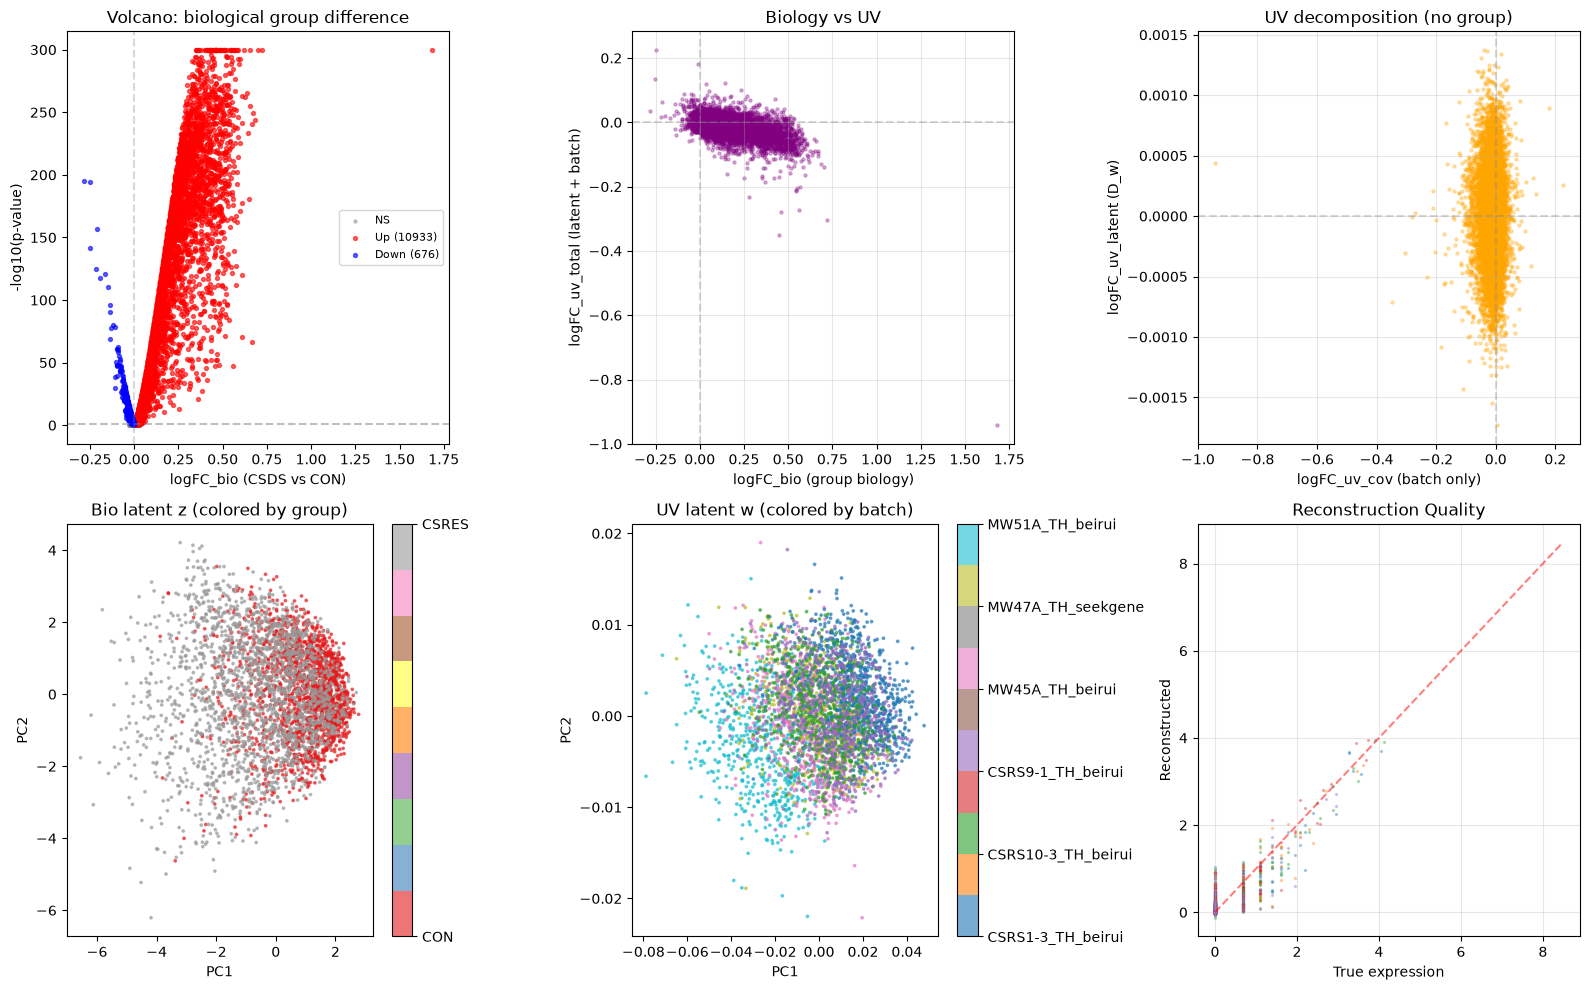

In [17]:
# ========== 6. 结果可视化：明确区分 group biology 与 UV ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 6a. Volcano plot：总 biological logFC（包含显式 group effect）
ax = axes[0, 0]
logFC = deg_df["logFC_bio"].values
pval = deg_df["p_value_empirical_t"].values
neg_log_p = -np.log10(pval + 1e-300)
sig_up = (pval < 0.05) & (logFC > 0)
sig_down = (pval < 0.05) & (logFC < 0)
ax.scatter(logFC[~sig_up & ~sig_down], neg_log_p[~sig_up & ~sig_down], c="gray", alpha=0.4, s=5, label="NS")
ax.scatter(logFC[sig_up], neg_log_p[sig_up], c="red", alpha=0.6, s=8, label=f"Up ({sig_up.sum()})")
ax.scatter(logFC[sig_down], neg_log_p[sig_down], c="blue", alpha=0.6, s=8, label=f"Down ({sig_down.sum()})")
ax.axhline(-np.log10(0.05), c="gray", ls="--", alpha=0.5)
ax.axvline(0, c="gray", ls="--", alpha=0.3)
ax.set_xlabel("logFC_bio (CSDS vs CON)"); ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano: biological group difference"); ax.legend(fontsize=8)

# 6b. Biological effect vs total UV
ax = axes[0, 1]
ax.scatter(deg_df["logFC_bio"], deg_df["logFC_uv_total"], alpha=0.3, s=5, c="purple")
ax.set_xlabel("logFC_bio (group biology)"); ax.set_ylabel("logFC_uv_total (latent + batch)")
ax.set_title("Biology vs UV"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3); ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6c. UV 分解：只显示 batch covariate 与 latent UV，不再把 W_group 画成 UV
ax = axes[0, 2]
ax.scatter(deg_df["logFC_uv_cov"], deg_df["logFC_uv_latent"], alpha=0.3, s=5, c="orange")
ax.set_xlabel("logFC_uv_cov (batch only)"); ax.set_ylabel("logFC_uv_latent (D_w)")
ax.set_title("UV decomposition (no group)"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3); ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6d. 生物学潜变量 z 的 PCA（按 group 着色）
z_mu = np.nan_to_num(extra["z_mu"], nan=0.0)
from sklearn.decomposition import PCA
z_pca = PCA(n_components=2).fit_transform(z_mu)
scatter = ax = axes[1, 0].scatter(
    z_pca[:, 0], z_pca[:, 1],
    c=[groups_unique.index(g) for g in group_labels],
    cmap="Set1", s=3, alpha=0.6,
)
axes[1, 0].set_title("Bio latent z (colored by group)")
axes[1, 0].set_xlabel("PC1"); axes[1, 0].set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=axes[1, 0], ticks=range(len(groups_unique)))
cbar.set_ticklabels(groups_unique)

# 6e. UV 潜变量 w 的 PCA（按 batch 着色）
w_mu = np.nan_to_num(extra["w_mu"], nan=0.0)
w_pca = PCA(n_components=2).fit_transform(w_mu)
scatter = axes[1, 1].scatter(
    w_pca[:, 0], w_pca[:, 1],
    c=[batches_unique.index(b) for b in batch_labels],
    cmap="tab10", s=3, alpha=0.6,
)
axes[1, 1].set_title("UV latent w (colored by batch)")
axes[1, 1].set_xlabel("PC1"); axes[1, 1].set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=axes[1, 1], ticks=range(len(batches_unique)))
cbar.set_ticklabels(batches_unique)

# 6f. 重建质量
ax = axes[1, 2]
model_cpu.eval()
with torch.no_grad():
    c_dict_cpu = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
    }
    out = model_cpu(torch.FloatTensor(Y_log), c_dict_cpu, torch.BoolTensor(neg_control_mask))
    y_recon = out["y_recon"].numpy()
idx_plot = np.random.choice(Y_log.shape[0], min(200, Y_log.shape[0]), replace=False)
for i in idx_plot[:5]:
    ax.scatter(Y_log[i, :200], y_recon[i, :200], s=2, alpha=0.3)
ax.plot([0, Y_log.max()], [0, Y_log.max()], "r--", alpha=0.5)
ax.set_xlabel("True expression"); ax.set_ylabel("Reconstructed")
ax.set_title("Reconstruction Quality"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
def compute_metrics(y_t, y_p):
    """向量化 R² + Pearson r（按基因 / 按样本 / 整体），无 for 循环"""
    # 整体 R²
    r2_total = float(r2_score(y_t.ravel(), y_p.ravel()))

    # 向量化按基因 Pearson r
    yt = y_t - y_t.mean(axis=0, keepdims=True)
    yp = y_p - y_p.mean(axis=0, keepdims=True)
    pearson_per_gene = (yt * yp).sum(axis=0) / \
        (np.sqrt((yt ** 2).sum(axis=0) * (yp ** 2).sum(axis=0)) + 1e-12)

    # 向量化按样本 Pearson r
    yt_c = y_t - y_t.mean(axis=1, keepdims=True)
    yp_c = y_p - y_p.mean(axis=1, keepdims=True)
    pearson_per_cell = (yt_c * yp_c).sum(axis=1) / \
        (np.sqrt((yt_c ** 2).sum(axis=1) * (yp_c ** 2).sum(axis=1)) + 1e-12)

    # 向量化按基因 R²
    ss_res_g = ((y_t - y_p) ** 2).sum(axis=0)
    ss_tot_g = ((y_t - y_t.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
    r2_per_gene = 1.0 - ss_res_g / ss_tot_g

    # 向量化按样本 R²
    ss_res_c = ((y_t - y_p) ** 2).sum(axis=1)
    ss_tot_c = ((y_t - y_t.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
    r2_per_cell = 1.0 - ss_res_c / ss_tot_c

    return {
        "r2_total": r2_total,
        "r2_per_gene_mean": float(np.mean(r2_per_gene)),
        "r2_per_gene_median": float(np.median(r2_per_gene)),
        "r2_per_cell_mean": float(np.mean(r2_per_cell)),
        "r2_per_cell_median": float(np.median(r2_per_cell)),
        "pearson_per_gene_mean": float(np.mean(pearson_per_gene)),
        "pearson_per_gene_median": float(np.median(pearson_per_gene)),
        "pearson_per_cell_mean": float(np.mean(pearson_per_cell)),
        "pearson_per_cell_median": float(np.median(pearson_per_cell)),
    }

=== Reconstruction Quality Evaluation ===

[Overall Reconstruction y_recon = y_bio - delta_lat - delta_cov]
  r2_total                    : 0.7146
  r2_per_gene_mean            : -42203768.0000
  r2_per_gene_median          : 0.0854
  r2_per_cell_mean            : 0.6807
  r2_per_cell_median          : 0.6820
  pearson_per_gene_mean       : 0.3421
  pearson_per_gene_median     : 0.2973
  pearson_per_cell_mean       : 0.8243
  pearson_per_cell_median     : 0.8260

[Biological Channel y_bio (Direct VAE output)]
  r2_total                    : 0.4136
  r2_per_gene_mean            : -40885376.0000
  r2_per_gene_median          : -0.0100
  r2_per_cell_mean            : 0.3175
  r2_per_cell_median          : 0.3480
  pearson_per_gene_mean       : 0.3354
  pearson_per_gene_median     : 0.2906
  pearson_per_cell_mean       : 0.6900
  pearson_per_cell_median     : 0.7609


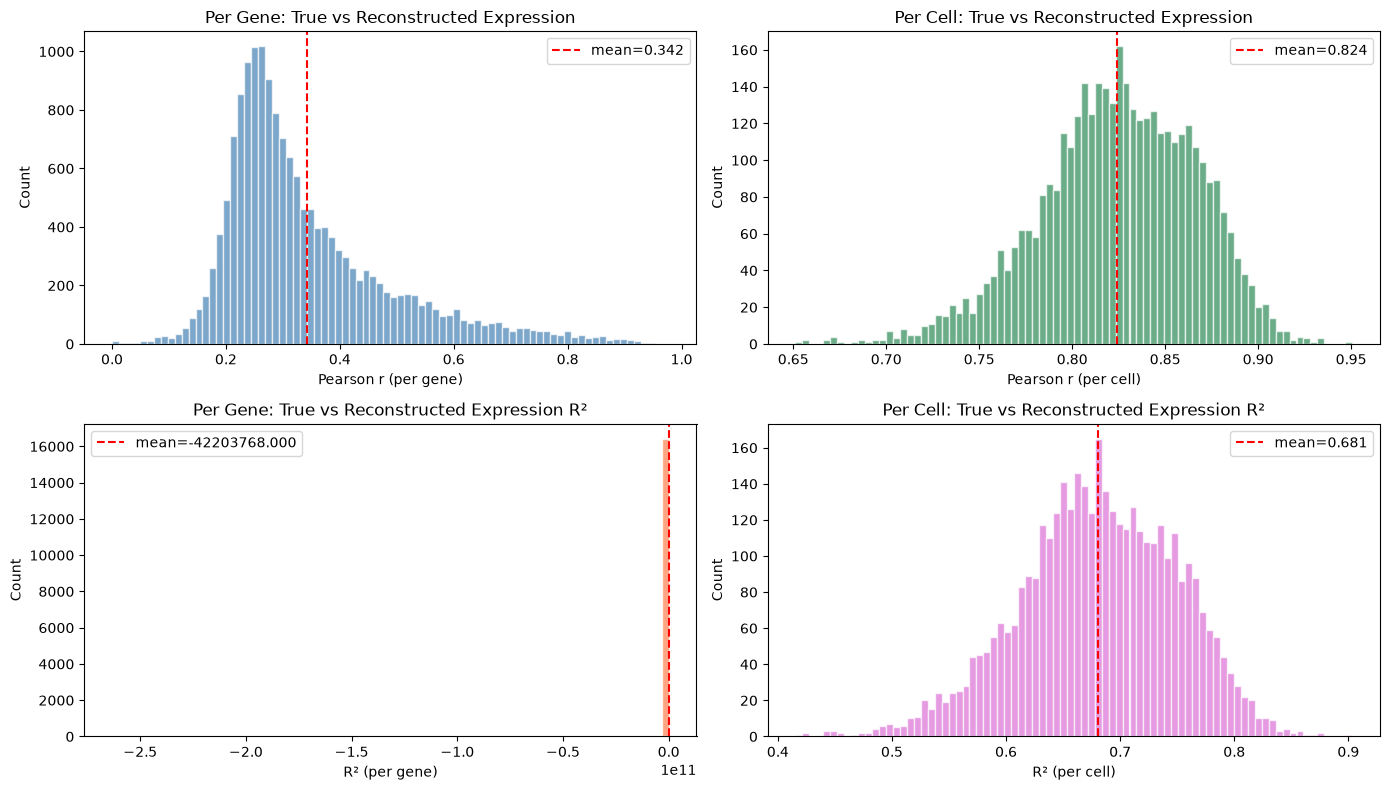


=== Reconstruction Quality Summary ===
Metric                                 y_recon (w/ UV)      y_bio (Clean)
---------------------------------------------------------------------------
r2_total                                        0.7146             0.4136
r2_per_gene_mean                        -42203768.0000     -40885376.0000
r2_per_gene_median                              0.0854            -0.0100
r2_per_cell_mean                                0.6807             0.3175
r2_per_cell_median                              0.6820             0.3480
pearson_per_gene_mean                           0.3421             0.3354
pearson_per_gene_median                         0.2973             0.2906
pearson_per_cell_mean                           0.8243             0.6900
pearson_per_cell_median                         0.8260             0.7609


In [19]:
# ========== 7. Reconstruction Quality Evaluation: R² + Pearson r ==========
from sklearn.metrics import r2_score
import torch
import numpy as np
import matplotlib.pyplot as plt

model_cpu.eval()
with torch.no_grad():
    c_dict_eval = {}
    group_idx = np.array([groups_unique.index(g) for g in group_labels])
    c_dict_eval["group"] = torch.FloatTensor(np.eye(len(groups_unique))[group_idx])
    batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
    c_dict_eval["batch"] = torch.FloatTensor(np.eye(len(batches_unique))[batch_idx])
    out_eval = model_cpu(torch.FloatTensor(Y_log), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_recon_eval = out_eval["y_recon"].numpy()
    y_bio_eval = out_eval["y_bio"].numpy()

y_true = Y_log


def compute_metrics(y_t, y_p):
    """Vectorized R² + Pearson r (per gene / per cell / overall), without for loops"""
    r2_total = float(r2_score(y_t.ravel(), y_p.ravel()))
    yt = y_t - y_t.mean(axis=0, keepdims=True)
    yp = y_p - y_p.mean(axis=0, keepdims=True)
    pearson_per_gene = (yt * yp).sum(axis=0) / \
        (np.sqrt((yt ** 2).sum(axis=0) * (yp ** 2).sum(axis=0)) + 1e-12)
    yt_c = y_t - y_t.mean(axis=1, keepdims=True)
    yp_c = y_p - y_p.mean(axis=1, keepdims=True)
    pearson_per_cell = (yt_c * yp_c).sum(axis=1) / \
        (np.sqrt((yt_c ** 2).sum(axis=1) * (yp_c ** 2).sum(axis=1)) + 1e-12)
    ss_res_g = ((y_t - y_p) ** 2).sum(axis=0)
    ss_tot_g = ((y_t - y_t.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
    r2_per_gene = 1.0 - ss_res_g / ss_tot_g
    ss_res_c = ((y_t - y_p) ** 2).sum(axis=1)
    ss_tot_c = ((y_t - y_t.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
    r2_per_cell = 1.0 - ss_res_c / ss_tot_c
    return {
        "r2_total": r2_total,
        "r2_per_gene_mean": float(np.mean(r2_per_gene)),
        "r2_per_gene_median": float(np.median(r2_per_gene)),
        "r2_per_cell_mean": float(np.mean(r2_per_cell)),
        "r2_per_cell_median": float(np.median(r2_per_cell)),
        "pearson_per_gene_mean": float(np.mean(pearson_per_gene)),
        "pearson_per_gene_median": float(np.median(pearson_per_gene)),
        "pearson_per_cell_mean": float(np.mean(pearson_per_cell)),
        "pearson_per_cell_median": float(np.median(pearson_per_cell)),
    }


print("=== Reconstruction Quality Evaluation ===\n")
metrics_recon = compute_metrics(y_true, y_recon_eval)
metrics_clean = compute_metrics(y_true, y_bio_eval)

print("[Overall Reconstruction y_recon = y_bio - delta_lat - delta_cov]")
for k, v in metrics_recon.items():
    print(f"  {k:<28}: {v:.4f}")

print("\n[Biological Channel y_bio (Direct VAE output)]")
for k, v in metrics_clean.items():
    print(f"  {k:<28}: {v:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

yt_ = y_true - y_true.mean(axis=0, keepdims=True)
yr_ = y_recon_eval - y_recon_eval.mean(axis=0, keepdims=True)
pearson_per_gene_arr = (yt_ * yr_).sum(axis=0) / (
    np.sqrt((yt_ ** 2).sum(axis=0) * (yr_ ** 2).sum(axis=0)) + 1e-12
)
axes[0, 0].hist(pearson_per_gene_arr, bins=80, color="steelblue", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(np.mean(pearson_per_gene_arr), color="red", ls="--",
                    label=f"mean={np.mean(pearson_per_gene_arr):.3f}")
axes[0, 0].set_xlabel("Pearson r (per gene)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Per Gene: True vs Reconstructed Expression")
axes[0, 0].legend()

yt_c = y_true - y_true.mean(axis=1, keepdims=True)
yr_c = y_recon_eval - y_recon_eval.mean(axis=1, keepdims=True)
pearson_per_cell_arr = (yt_c * yr_c).sum(axis=1) / (
    np.sqrt((yt_c ** 2).sum(axis=1) * (yr_c ** 2).sum(axis=1)) + 1e-12
)
axes[0, 1].hist(pearson_per_cell_arr, bins=80, color="seagreen", alpha=0.7, edgecolor="white")
axes[0, 1].axvline(np.mean(pearson_per_cell_arr), color="red", ls="--",
                    label=f"mean={np.mean(pearson_per_cell_arr):.3f}")
axes[0, 1].set_xlabel("Pearson r (per cell)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Per Cell: True vs Reconstructed Expression")
axes[0, 1].legend()

ss_res_g = ((y_true - y_recon_eval) ** 2).sum(axis=0)
ss_tot_g = ((y_true - y_true.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
r2_per_gene_arr = 1.0 - ss_res_g / ss_tot_g
axes[1, 0].hist(r2_per_gene_arr, bins=80, color="coral", alpha=0.7, edgecolor="white")
axes[1, 0].axvline(np.mean(r2_per_gene_arr), color="red", ls="--",
                    label=f"mean={np.mean(r2_per_gene_arr):.3f}")
axes[1, 0].set_xlabel("R² (per gene)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Per Gene: True vs Reconstructed Expression R²")
axes[1, 0].legend()

ss_res_c = ((y_true - y_recon_eval) ** 2).sum(axis=1)
ss_tot_c = ((y_true - y_true.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
r2_per_cell_arr = 1.0 - ss_res_c / ss_tot_c
axes[1, 1].hist(r2_per_cell_arr, bins=80, color="orchid", alpha=0.7, edgecolor="white")
axes[1, 1].axvline(np.mean(r2_per_cell_arr), color="red", ls="--",
                    label=f"mean={np.mean(r2_per_cell_arr):.3f}")
axes[1, 1].set_xlabel("R² (per cell)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Per Cell: True vs Reconstructed Expression R²")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n=== Reconstruction Quality Summary ===")
print(f"{'Metric':<35} {'y_recon (w/ UV)':>18} {'y_bio (Clean)':>18}")
print("-" * 75)
for k in metrics_recon:
    print(f"{k:<35} {metrics_recon[k]:>18.4f} {metrics_clean[k]:>18.4f}")